# Network Intrusion Detection — Exploratory Data Analysis

**Dataset**: NSL-KDD (improved version of the classic KDD Cup 1999 dataset)  
**Train records**: 125,973 | **Test records**: 22,544 | **Features**: 41

**Target**: Binary — `normal` (0) vs. any attack type (1)

## What Makes NSL-KDD Different from Credit Risk?
- **Mixed feature types**: continuous + binary + categorical (protocol, service, flag)
- **Multi-class labels** that we binarize (neptune, smurf, back → all 'attack')
- **Pre-split train/test**: The dataset provides official splits — we respect them
- **Network domain features**: traffic statistics, connection counts, error rates

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
print('Imports OK')

Imports OK


## 1. Load the Data

NSL-KDD has no header row — we supply column names manually.

In [2]:
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

train_df = pd.read_csv('../data/raw/network_intrusion/KDDTrain+.txt',
                       header=None, names=column_names)
test_df  = pd.read_csv('../data/raw/network_intrusion/KDDTest+.txt',
                       header=None, names=column_names)

# Drop the difficulty_level meta column
train_df = train_df.drop(columns=['difficulty_level'])
test_df  = test_df.drop(columns=['difficulty_level'])

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (125973, 42)
Test shape:  (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 2. Label Analysis

The raw labels are attack type names (neptune, smurf, etc.).
We binarize them: `normal` → 0, everything else → 1 (attack).
This makes it a binary classification problem.

=== Training Set Raw Labels ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2


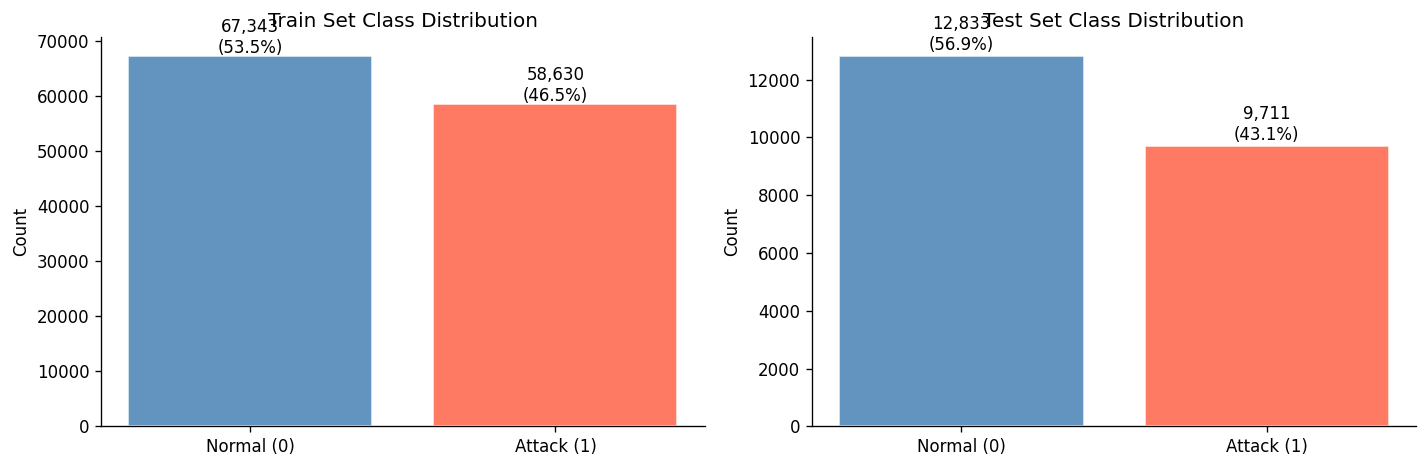

In [3]:
# Raw label distribution
print('=== Training Set Raw Labels ===')
print(train_df['label'].value_counts().to_string())

# Binarize
train_df['binary_label'] = (train_df['label'] != 'normal').astype(int)
test_df['binary_label']  = (test_df['label']  != 'normal').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
counts_train = train_df['binary_label'].value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], counts_train.values,
            color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white')
axes[0].set_title('Train Set Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_train.values):
    pct = v / len(train_df) * 100
    axes[0].text(i, v + 500, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=10)

# Test
counts_test = test_df['binary_label'].value_counts()
axes[1].bar(['Normal (0)', 'Attack (1)'], counts_test.values,
            color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white')
axes[1].set_title('Test Set Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_test.values):
    pct = v / len(test_df) * 100
    axes[1].text(i, v + 200, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../models/network_intrusion/eda_class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Categorical Features

Three categorical features need special handling:
- `protocol_type`: tcp, udp, icmp — network protocol
- `service`: http, ftp, smtp, etc. — network service
- `flag`: SF, S0, REJ, etc. — connection status

We'll use **OneHotEncoder** for these (not label encoding) to avoid
implying any ordinal relationship between categories.

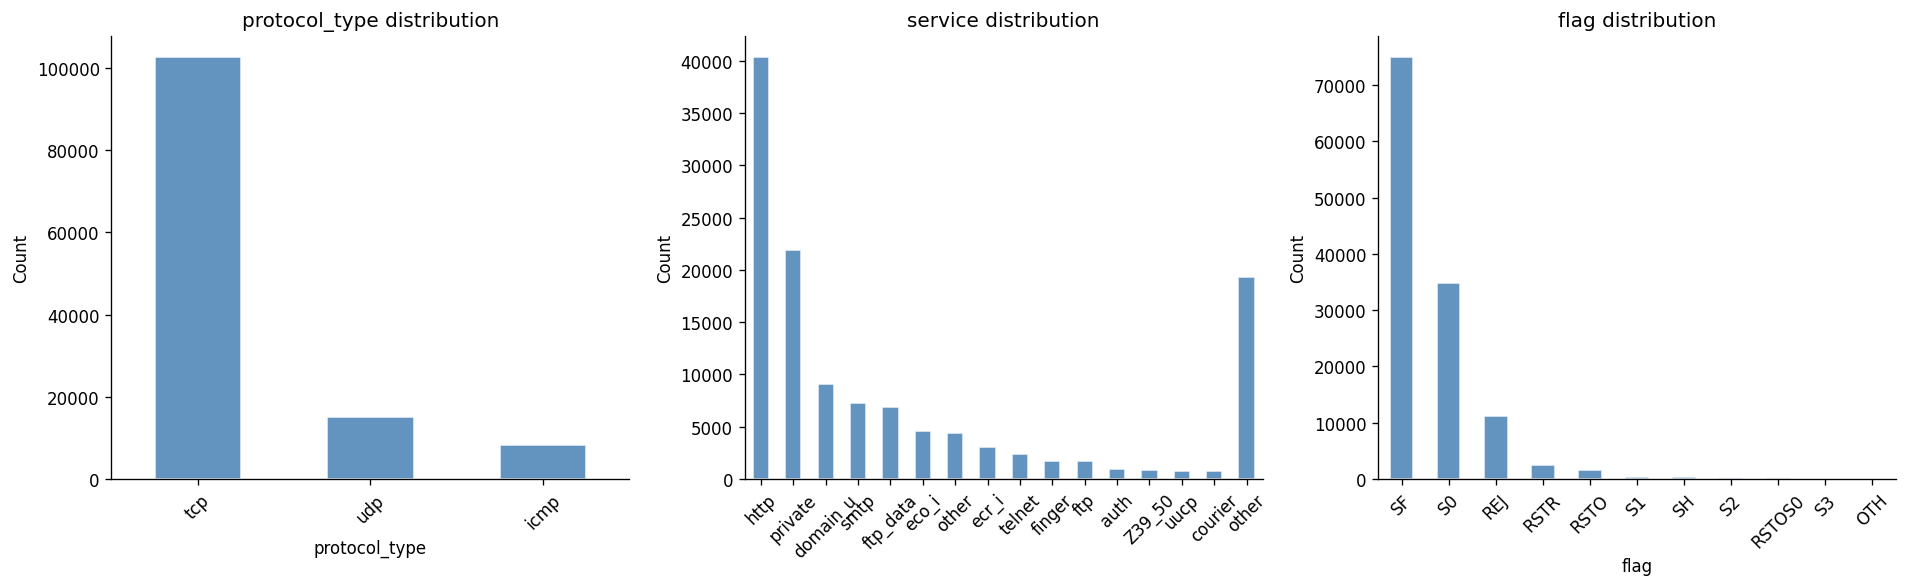

Attack rate by protocol_type:
protocol_type
icmp    0.842
tcp     0.478
udp     0.171


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['protocol_type', 'service', 'flag']):
    vc = train_df[col].value_counts()
    # Show only top 15 for service (has many values)
    if len(vc) > 15:
        other_count = vc[15:].sum()
        vc = pd.concat([vc[:15], pd.Series({'other': other_count})])
    vc.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title(f'{col} distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../models/network_intrusion/eda_categoricals.png', bbox_inches='tight')
plt.show()

# Attack rate by protocol
print('Attack rate by protocol_type:')
print(train_df.groupby('protocol_type')['binary_label'].mean().round(3).to_string())

## 4. Numeric Feature Distributions

Many network features (src_bytes, dst_bytes, count) are highly skewed —
normal traffic often has near-zero values while attacks have extreme spikes.

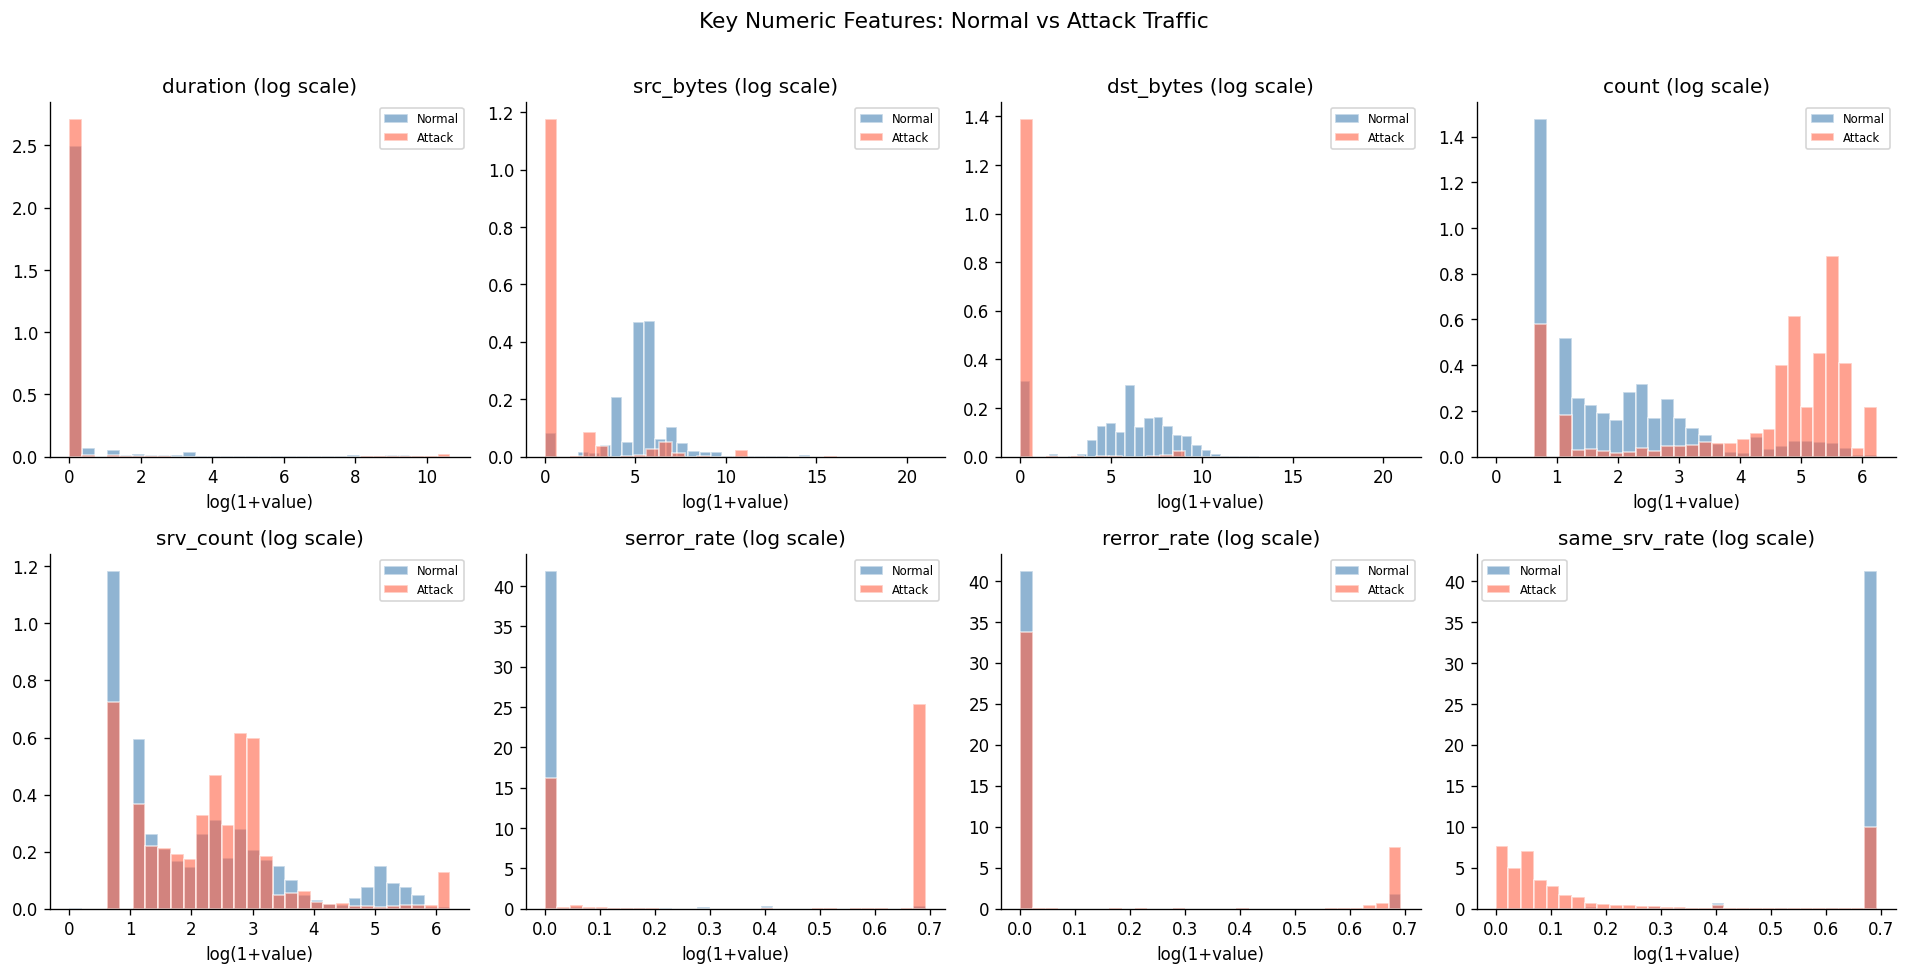

In [5]:
key_numeric = ['duration', 'src_bytes', 'dst_bytes', 'count',
               'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_numeric):
    for label in [0, 1]:
        color = 'steelblue' if label == 0 else 'tomato'
        lbl = 'Normal' if label == 0 else 'Attack'
        vals = train_df[train_df['binary_label'] == label][col]
        ax.hist(np.log1p(vals), bins=30, alpha=0.6, color=color,
                density=True, edgecolor='white', label=lbl)
    ax.set_title(f'{col} (log scale)')
    ax.set_xlabel('log(1+value)')
    ax.legend(fontsize=7)

plt.suptitle('Key Numeric Features: Normal vs Attack Traffic', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../models/network_intrusion/eda_numeric_features.png', bbox_inches='tight')
plt.show()

## 5. Feature Correlation with Target

Point-biserial correlation between each numeric feature and the binary label.
This gives us a quick signal of which features are most discriminative.

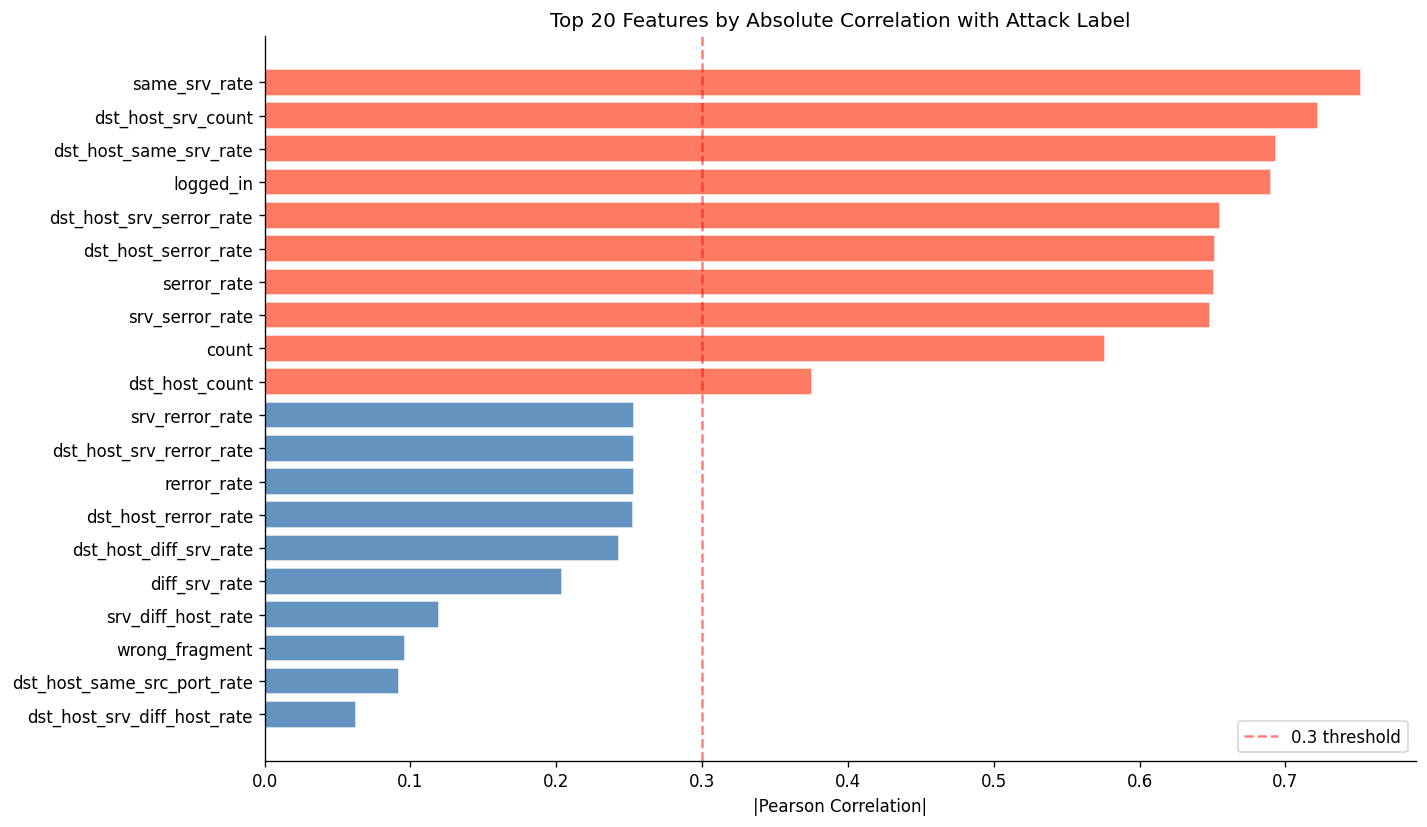

Top 15 features by correlation with attack label:
same_srv_rate               0.7519
dst_host_srv_count          0.7225
dst_host_same_srv_rate      0.6938
logged_in                   0.6902
dst_host_srv_serror_rate    0.6550
dst_host_serror_rate        0.6518
serror_rate                 0.6507
srv_serror_rate             0.6483
count                       0.5764
dst_host_count              0.3751
srv_rerror_rate             0.2535
dst_host_srv_rerror_rate    0.2534
rerror_rate                 0.2534
dst_host_rerror_rate        0.2526
dst_host_diff_srv_rate      0.2429


In [6]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['binary_label']]

corr_with_target = (
    train_df[numeric_cols + ['binary_label']]
    .corr()['binary_label']
    .drop('binary_label')
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))
top20 = corr_with_target.head(20)
colors = ['tomato' if v > 0.3 else 'steelblue' for v in top20.values]
plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], alpha=0.85, edgecolor='white')
plt.title('Top 20 Features by Absolute Correlation with Attack Label', fontsize=12)
plt.xlabel('|Pearson Correlation|')
plt.axvline(0.3, color='red', linestyle='--', alpha=0.5, label='0.3 threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../models/network_intrusion/eda_feature_correlations.png', bbox_inches='tight')
plt.show()

print('Top 15 features by correlation with attack label:')
print(corr_with_target.head(15).round(4).to_string())

## 6. Train/Test Distribution Check

NSL-KDD's test set is intentionally harder than the train set — it contains
attack types not seen during training. This is realistic but means our test
metrics may be lower than train metrics even without overfitting.

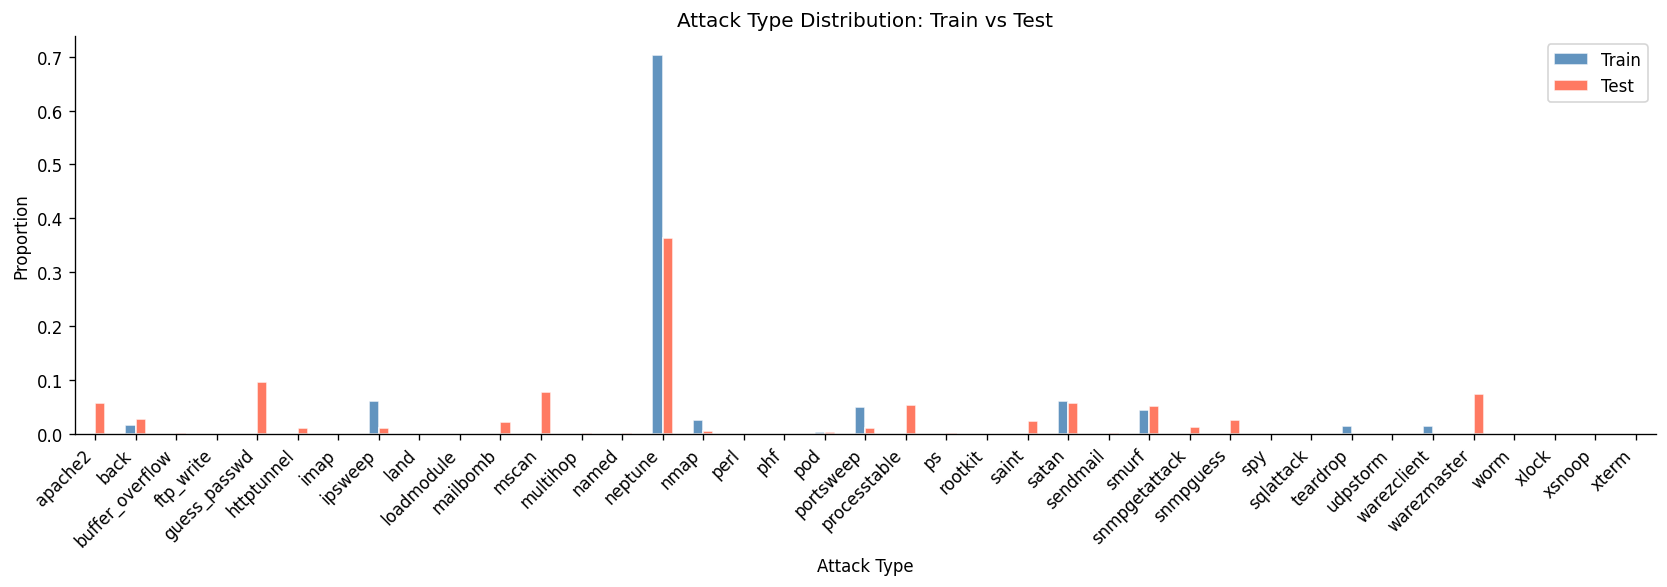

Attack types in TEST but NOT in TRAIN: {'xterm', 'snmpgetattack', 'worm', 'processtable', 'snmpguess', 'sendmail', 'named', 'httptunnel', 'udpstorm', 'mailbomb', 'saint', 'xsnoop', 'xlock', 'sqlattack', 'ps', 'apache2', 'mscan'}
These unseen attack types make this a realistic but harder generalization test.


In [7]:
# Compare attack type distributions between train and test
train_attack_types = train_df[train_df['binary_label']==1]['label'].value_counts(normalize=True)
test_attack_types  = test_df[test_df['binary_label']==1]['label'].value_counts(normalize=True)

comparison = pd.DataFrame({
    'Train': train_attack_types,
    'Test': test_attack_types
}).fillna(0).round(4)

comparison.plot(kind='bar', figsize=(14, 5), color=['steelblue', 'tomato'],
               alpha=0.85, edgecolor='white')
plt.title('Attack Type Distribution: Train vs Test')
plt.ylabel('Proportion')
plt.xlabel('Attack Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../models/network_intrusion/eda_train_test_comparison.png', bbox_inches='tight')
plt.show()

# Flag attack types in test but not in train
train_types = set(train_df['label'].unique())
test_types  = set(test_df['label'].unique())
novel_types = test_types - train_types
if novel_types:
    print(f'Attack types in TEST but NOT in TRAIN: {novel_types}')
    print('These unseen attack types make this a realistic but harder generalization test.')

## 7. EDA Summary — What We Learned

| Finding | Implication |
|---|---|
| 3 categorical features (protocol, service, flag) | OneHotEncoder in pipeline |
| Highly skewed numeric features | StandardScaler handles this |
| serror_rate, rerror_rate highly correlated with attack | Strong features for model |
| Test set has novel attack types | Realistic generalization challenge |
| ~52% attacks in train set | Near-balanced — less imbalance than credit risk |

### Key Features to Watch (from correlation analysis)
1. `serror_rate` / `dst_host_serror_rate` — SYN flood attacks cause high SYN error rates
2. `logged_in` — Attacks often happen without a successful login
3. `dst_host_srv_count` — DoS attacks generate many connections to the same service
4. `flag` (SF=normal connection vs S0/REJ=failed) — huge discriminative power after encoding